In [ ]:
%matplotlib inline
import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True'
os.environ[ 'NUMBA_CACHE_DIR' ] = '.'
#os.environ['PYENSEMBL_CACHE_DIR'] = '.'
os.environ['GYPSUM_CACHE_DIR'] = '.'
os.environ['CACHE_DIRECTORY'] = '.'
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import scimap as sm
import scanpy.external as sce
from pyensembl import EnsemblRelease
from pyensembl import Genome
import matplotlib.pyplot as plt
%matplotlib inline
import singler
import singlecellexperiment as scet
import celldex

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr
from IPython.display import Image, display

import celltypist
from celltypist import models
import harmonypy


Running SCIMAP  2.0.3


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

scanpy==1.10.1 anndata==0.10.7 umap==0.5.5 numpy==1.26.4 scipy==1.11.0 pandas==1.5.3 scikit-learn==1.4.2 statsmodels==0.14.1 igraph==0.10.8 pynndescent==0.5.12


In [ ]:
#pyensembl
ensembl_ig_tr_genes = 'file'
#clustering
clustering_n_neighbors=10
clustering_n_pcs=40
clustering_resolution = 0.5
#highly variable genes selection
hvg_min_mean=0.0125
hvg_max_mean=3
hvg_min_disp=0.5
Anno_model = "Immune_All_Low.pkl"
#clustree
#parares = [0.1,0.3,0.5,0.7,0.9]

In [ ]:
filelist_all = os.listdir("./")

filelist = [x for x in filelist_all if x.endswith("h5ad")]

In [ ]:
SRR = [os.path.splitext(os.path.basename(file))[0] for file in filelist]

In [7]:
adatas = [sc.read_h5ad(os.path.splitext(os.path.basename(file))[0]+'.h5ad') for file in filelist]

In [ ]:
adatas

### Normalization and log transformation

In [8]:
for i in range(len(adatas)):
    sc.pp.normalize_total(adatas[i], target_sum=1e4)
    sc.pp.log1p(adatas[i])
    #sc.pp.scale(adatas[i], max_value=10)

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


In [9]:
adatas_raw = adatas

### Remove tr and ig genes from gene features

In [10]:
#data = EnsemblRelease(release=ensembl_release, species=ensembl_species)
#data.download()
#data.index()

In [ ]:
#gene_ids = data.gene_ids()

In [12]:
#genes = [data.gene_by_id(gene_id) for gene_id in gene_ids]

In [13]:
#tr_ig_genes = [gene for gene in genes if gene.biotype in ["TR_C_gene", "TR_D_gene","TR_J_gene", 
#                                                           "TR_J_pseudogene","TR_V_gene", "TR_V_pseudogene","IG_C_gene", "IG_C_pseudogene","IG_D_gene", 
#                                                          "IG_D_pseudogene","IG_J_gene", "IG_LV_gene", "IG_pseudogene","IG_V_gene","IG_V_pseudogene"]]

In [14]:
#lst1 = [tr_ig_genes[i].gene_id for i in range(len(tr_ig_genes))]
#lst2 = [tr_ig_genes[i].gene_name for i in range(len(tr_ig_genes))]
#feature=pd.DataFrame(
#    {'es':lst1,
#     'id':lst2
#   }
#)

In [ ]:
feature = pd.read_csv(ensembl_ig_tr_genes+".csv", header=0)

In [ ]:
for i in range(len(adatas)):
    num = adatas[i].var.gene_ids.to_numpy()
    list = feature.loc[feature['ensemble_id'].isin(num)]
    boom = list.gene_name.to_numpy()
    adatas[i]=sm.hl.dropFeatures(adatas[i], drop_markers= boom ,subset_raw=False)

### Identify highly-variable genes

In [ ]:
for i, adata in enumerate(adatas):
    plt.figure(figsize=(8, 6))
    sc.pp.highly_variable_genes(adata, min_mean=hvg_min_mean, max_mean=hvg_max_mean, min_disp=hvg_min_disp)
    sc.pl.highly_variable_genes(adata, show=False)

### Principal component analysis

In [ ]:
for i, adata in enumerate(adatas):
    plt.figure(figsize=(8, 6))
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pl.pca_variance_ratio(adata, log=True, show=False)

### Computing the neighborhood graph

In [19]:
for i in range(len(adatas)):
  sc.pp.neighbors(adatas[i], n_neighbors = clustering_n_neighbors, n_pcs=clustering_n_pcs)


computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbor

### Embedding and clustering the neighborhood graph

In [ ]:
for i in range(len(adatas)):
    sc.tl.umap(adatas[i])
    sc.tl.leiden(adatas[i],resolution=clustering_resolution)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:11)
running Leiden clustering
    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)
running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:11)
running Leiden clustering
    finished: found 17 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:12)
running Leiden clustering
    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)
running Lei

In [ ]:
for i, adata in enumerate(adatas):
    plt.figure(figsize=(8, 6))
    sc.pl.umap(adata, color=['leiden'],show =False)

### Cell type annotation

In [ ]:
# ref_data = celldex.fetch_reference("dice", "2024-02-26", realize_assays=True)
# for i in range(len(adatas)):
#     data = adatas[i]
#     scedata = scet.SingleCellExperiment.from_anndata(data) 
#     mat = scedata.assay("X")
#     features = data.var_names
#     result = singler.annotate_single(
#         test_data = mat,
#         test_features = features,
#         ref_data = ref_data,
#         ref_labels = "label.fine",)
#     adatas[i].obs['cell_type'] = result.column("best")

In [ ]:
#models.download_models(force_update=False)
models.download_models(model=Anno_model)

In [ ]:
model = models.Model.load(model = Anno_model)

In [ ]:
for i in range(len(adatas)):
    data = adatas[i].copy()
    # Annotate
    predictions = celltypist.annotate(
        data,
        model=model,
        majority_voting=True
    )
    
    # Write to adata
    adatas[i].obs["cell_type"]               = predictions.predicted_labels["predicted_labels"]
    adatas[i].obs["cell_type_majority_vote"] = predictions.predicted_labels["majority_voting"]
    #adatas[i].obs["cell_type_conf_score"]    = predictions.predicted_labels["conf_score"]

### Integration

In [24]:
adatas_concat = ad.concat([adatas[i] for i in range(len(adatas))], join="inner",index_unique="-",keys= SRR)

extracting highly variable genes


... storing 'cell_type' as categorical


    finished (0:00:05)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


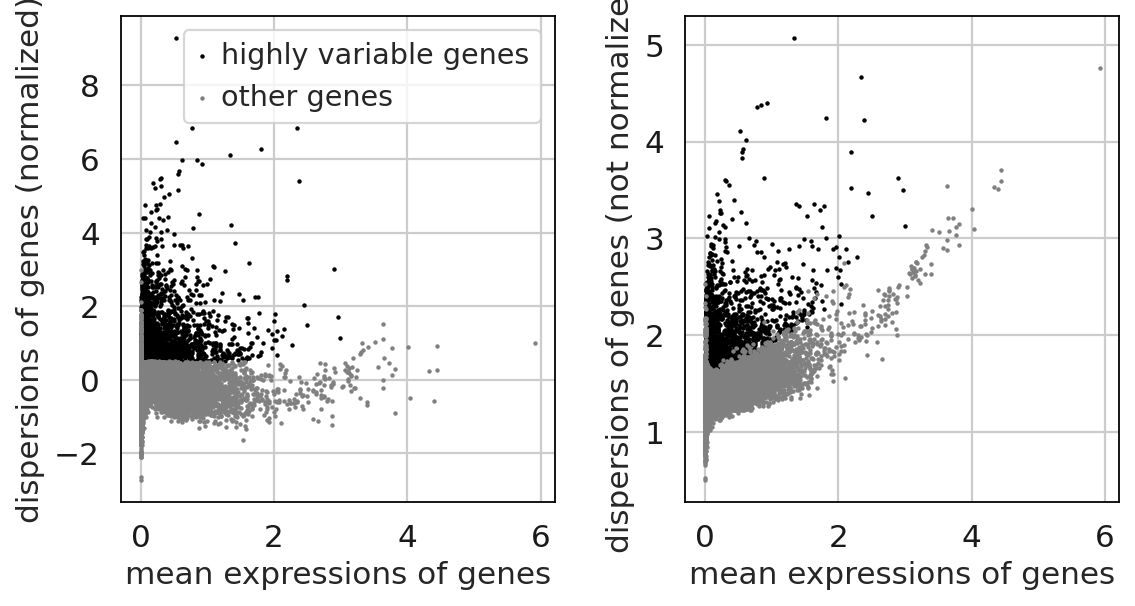

In [25]:

sc.pp.highly_variable_genes(adatas_concat, min_mean=hvg_min_mean, max_mean=hvg_max_mean, min_disp=hvg_min_disp,batch_key="sample")


sc.pl.highly_variable_genes(adatas_concat)

In [27]:
adatas_concat = adatas_concat[:,adatas_concat.var.highly_variable]

In [28]:
sc.pp.pca(adatas_concat)
sc.pp.neighbors(adatas_concat)
sc.tl.umap(adatas_concat)
sc.tl.leiden(adatas_concat)

computing PCA
    with n_comps=50
    finished (0:00:07)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:03)
running Leiden clustering
    finished: found 23 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:59)


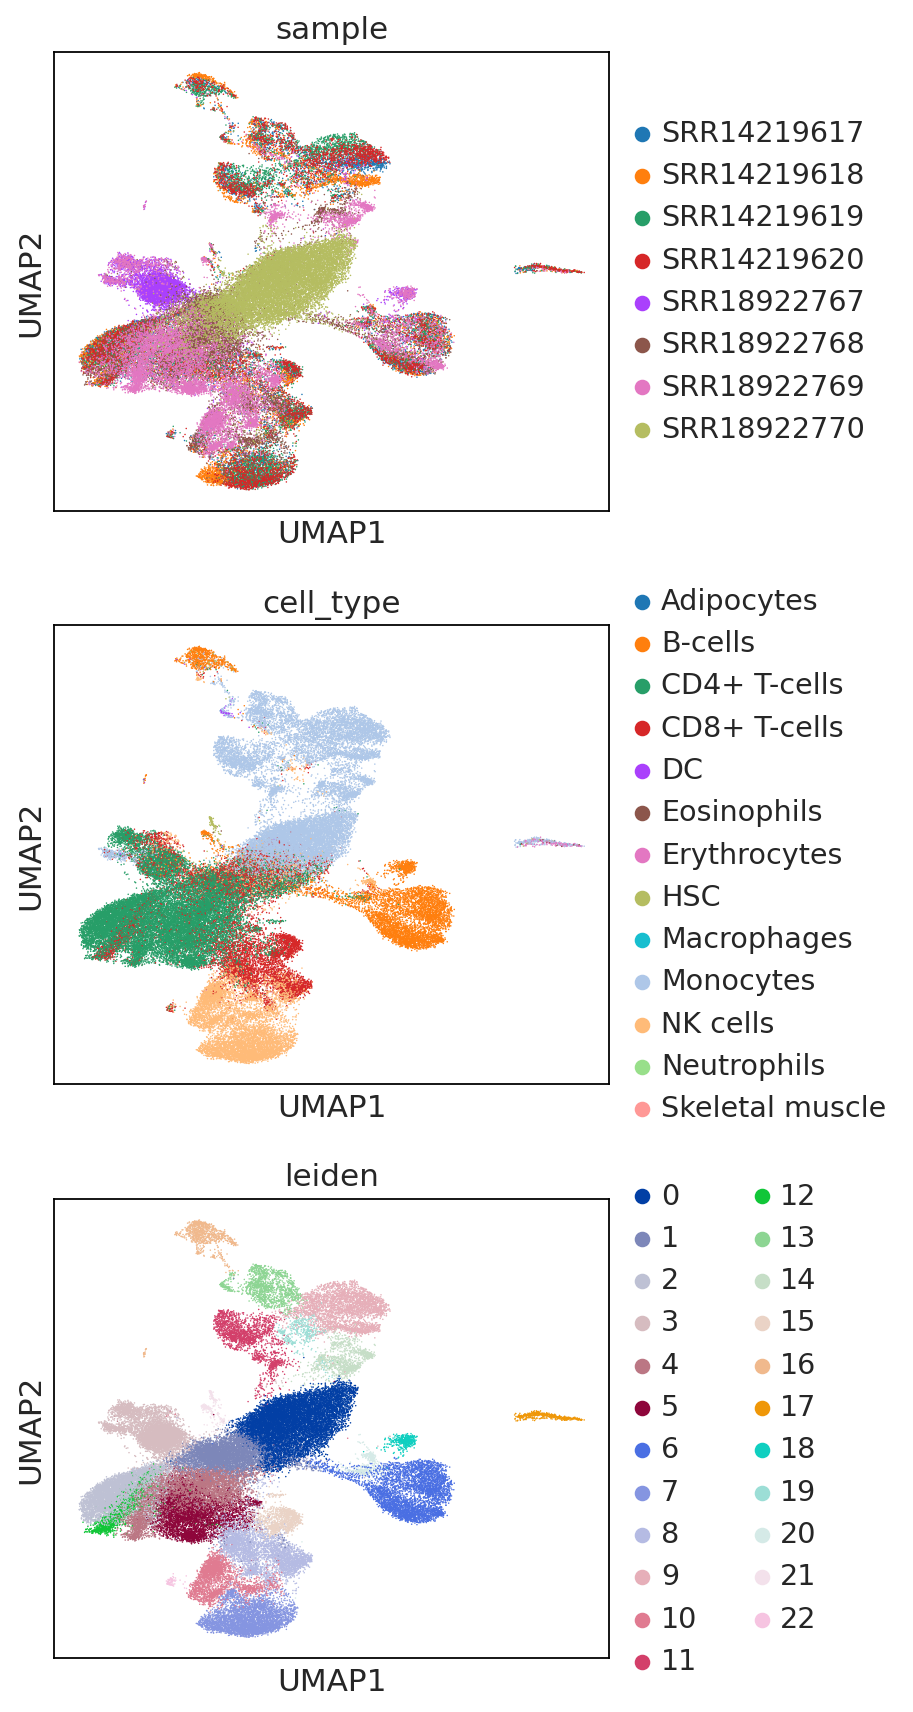

In [29]:
sc.pl.umap(adatas_concat, color=["sample", "cell_type","leiden"],ncols=1)

In [ ]:
#sce.pp.harmony_integrate(adatas_concat, 'sample')
ho = harmonypy.run_harmony(
    adatas_concat.obsm['X_pca'].astype(np.float64),
    adatas_concat.obs,
    'sample'
)
adatas_concat.obsm['X_pca_harmony'] = ho.Z_corr

2024-05-22 18:58:44,207 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
INFO:harmonypy:Computing initial centroids with sklearn.KMeans...
2024-05-22 18:58:59,525 - harmonypy - INFO - sklearn.KMeans initialization complete.
INFO:harmonypy:sklearn.KMeans initialization complete.
2024-05-22 18:58:59,805 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2024-05-22 18:59:25,365 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2024-05-22 18:59:49,195 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2024-05-22 19:00:13,128 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2024-05-22 19:00:36,125 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2024-05-22 19:00:59,236 - harmonypy - INFO - Iteration 6 of 10
INFO:harmonypy:Iteration 6 of 10
2024-05-22 19:01:21,142 - harmonypy - INFO - Iteration 7 of 10
INFO:harmonypy:Iteration 7 of 10
2024-05-22 19:01:43,019 - 

In [ ]:
sc.pp.neighbors(adatas_concat, n_pcs =30, use_rep = "X_pca_harmony")
sc.tl.umap(adatas_concat)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:02)


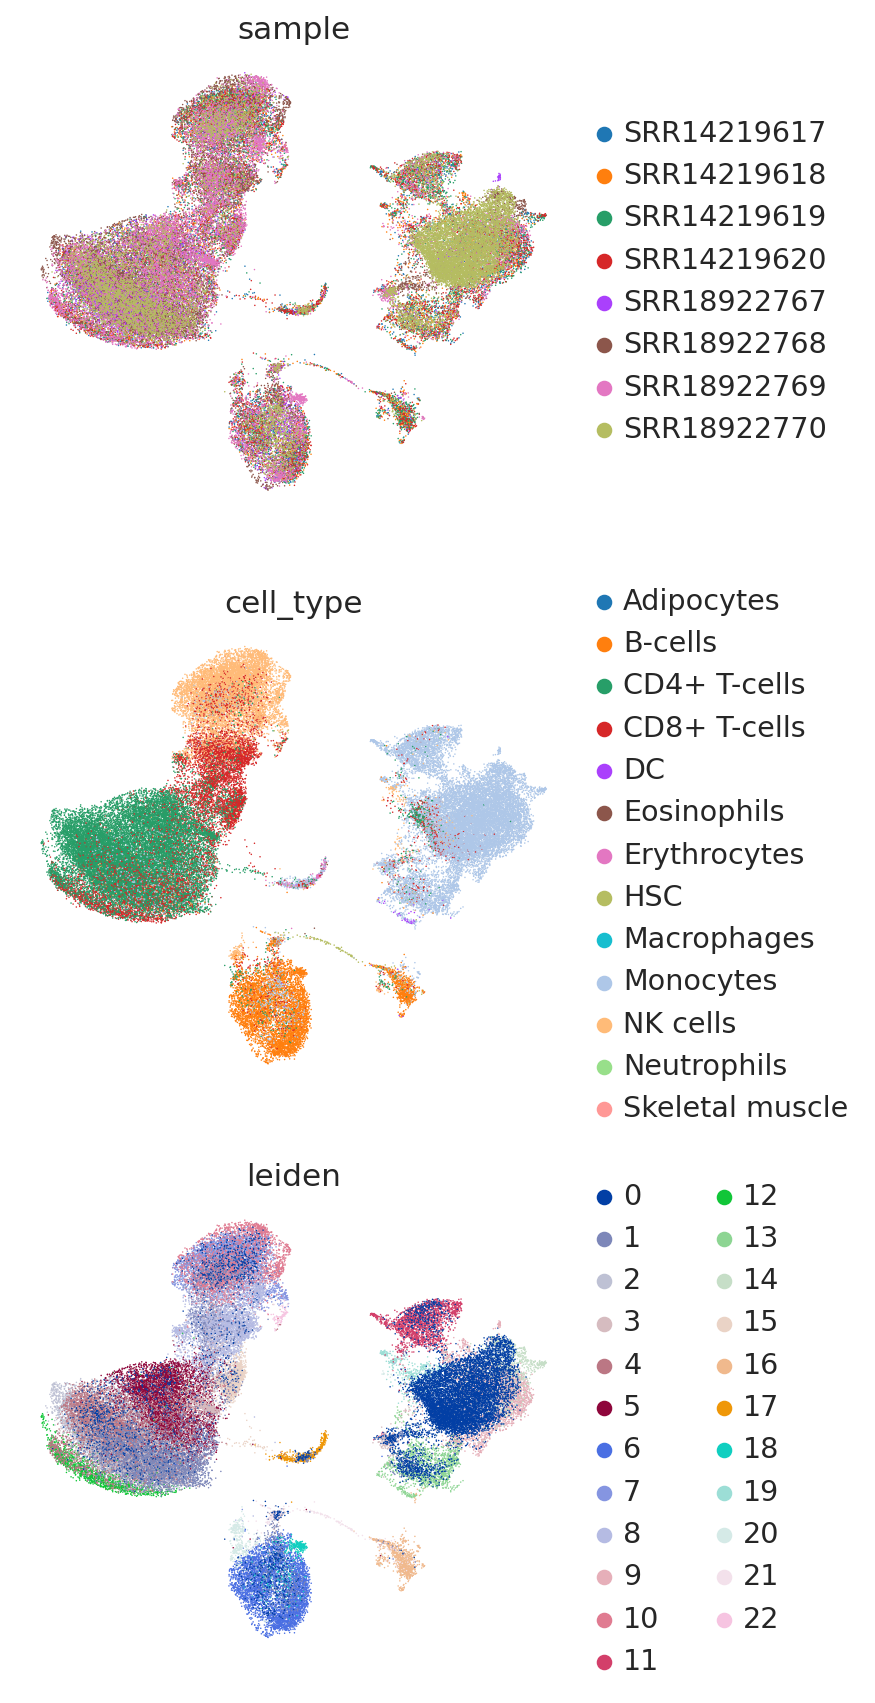

In [ ]:
sc.pl.umap(adatas_concat, color=["sample", "cell_type","leiden"], frameon=False, ncols=1)

In [ ]:
adatas_concat.write('concat.h5ad')

AnnData object with n_obs × n_vars = 65003 × 3409
    obs: 'sample', 'species', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'sample_colors', 'cell_type_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### Clustree

In [115]:
parares = [0.1,0.3,0.5,0.7,0.9]

In [ ]:
for i in range(len(adatas)):
    globals()['df'+str(i)]=pd.DataFrame({'cell':adatas[i].obs.leiden.index})
    #for res in np.linspace(1,0.5,5):
    for res in parares:
        sc.tl.leiden(adatas[i],resolution=res)
        df=pd.DataFrame(adatas[i].obs.leiden.values)
        globals()['df'+str(i)] = pd.concat([globals()['df'+str(i)],df], axis=1)
        #globals()['df'+str(i)] = globals()['df'+str(i)].join(globals()['df'+str(res)])

running Leiden clustering
    finished: found 10 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 20 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 22 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:01)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 12 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
running Leiden clustering
    finished: found 17 

In [ ]:
df=pd.DataFrame({'cell':adatas_concat.obs.leiden.index})
for res in parares:
    sc.tl.leiden(adatas_concat,resolution=res)
    dm=pd.DataFrame(adatas_concat.obs.leiden.values)
    df=pd.concat([df,dm],axis=1)

running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:29)
running Leiden clustering
    finished: found 9 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:36)
running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:00)
running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:03)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:00)


In [117]:
parares = ['K_' + str(num) for num in parares]

In [118]:
parares.insert(0,"cell")

In [119]:
for i in range(len(adatas)):
    globals()['df'+str(i)].columns = parares
    globals()['df'+str(i)].set_index("cell", inplace = True)

In [56]:
df.columns = parares
df.set_index("cell", inplace = True)

In [120]:
for i in range(len(adatas)):
    globals()['df'+str(i)]=globals()['df'+str(i)].astype("int")
    globals()['df'+str(i)]+=1
    #globals()['df'+str(i)]=globals()['df'+str(i)].sort_values(by=['K1'],ascending=True)

In [57]:
df=df.astype("int")
df+=1

In [121]:
for i in range(len(adatas)):
    globals()['df'+str(i)]=globals()['df'+str(i)].astype("category")

In [60]:
df=df.astype("category")

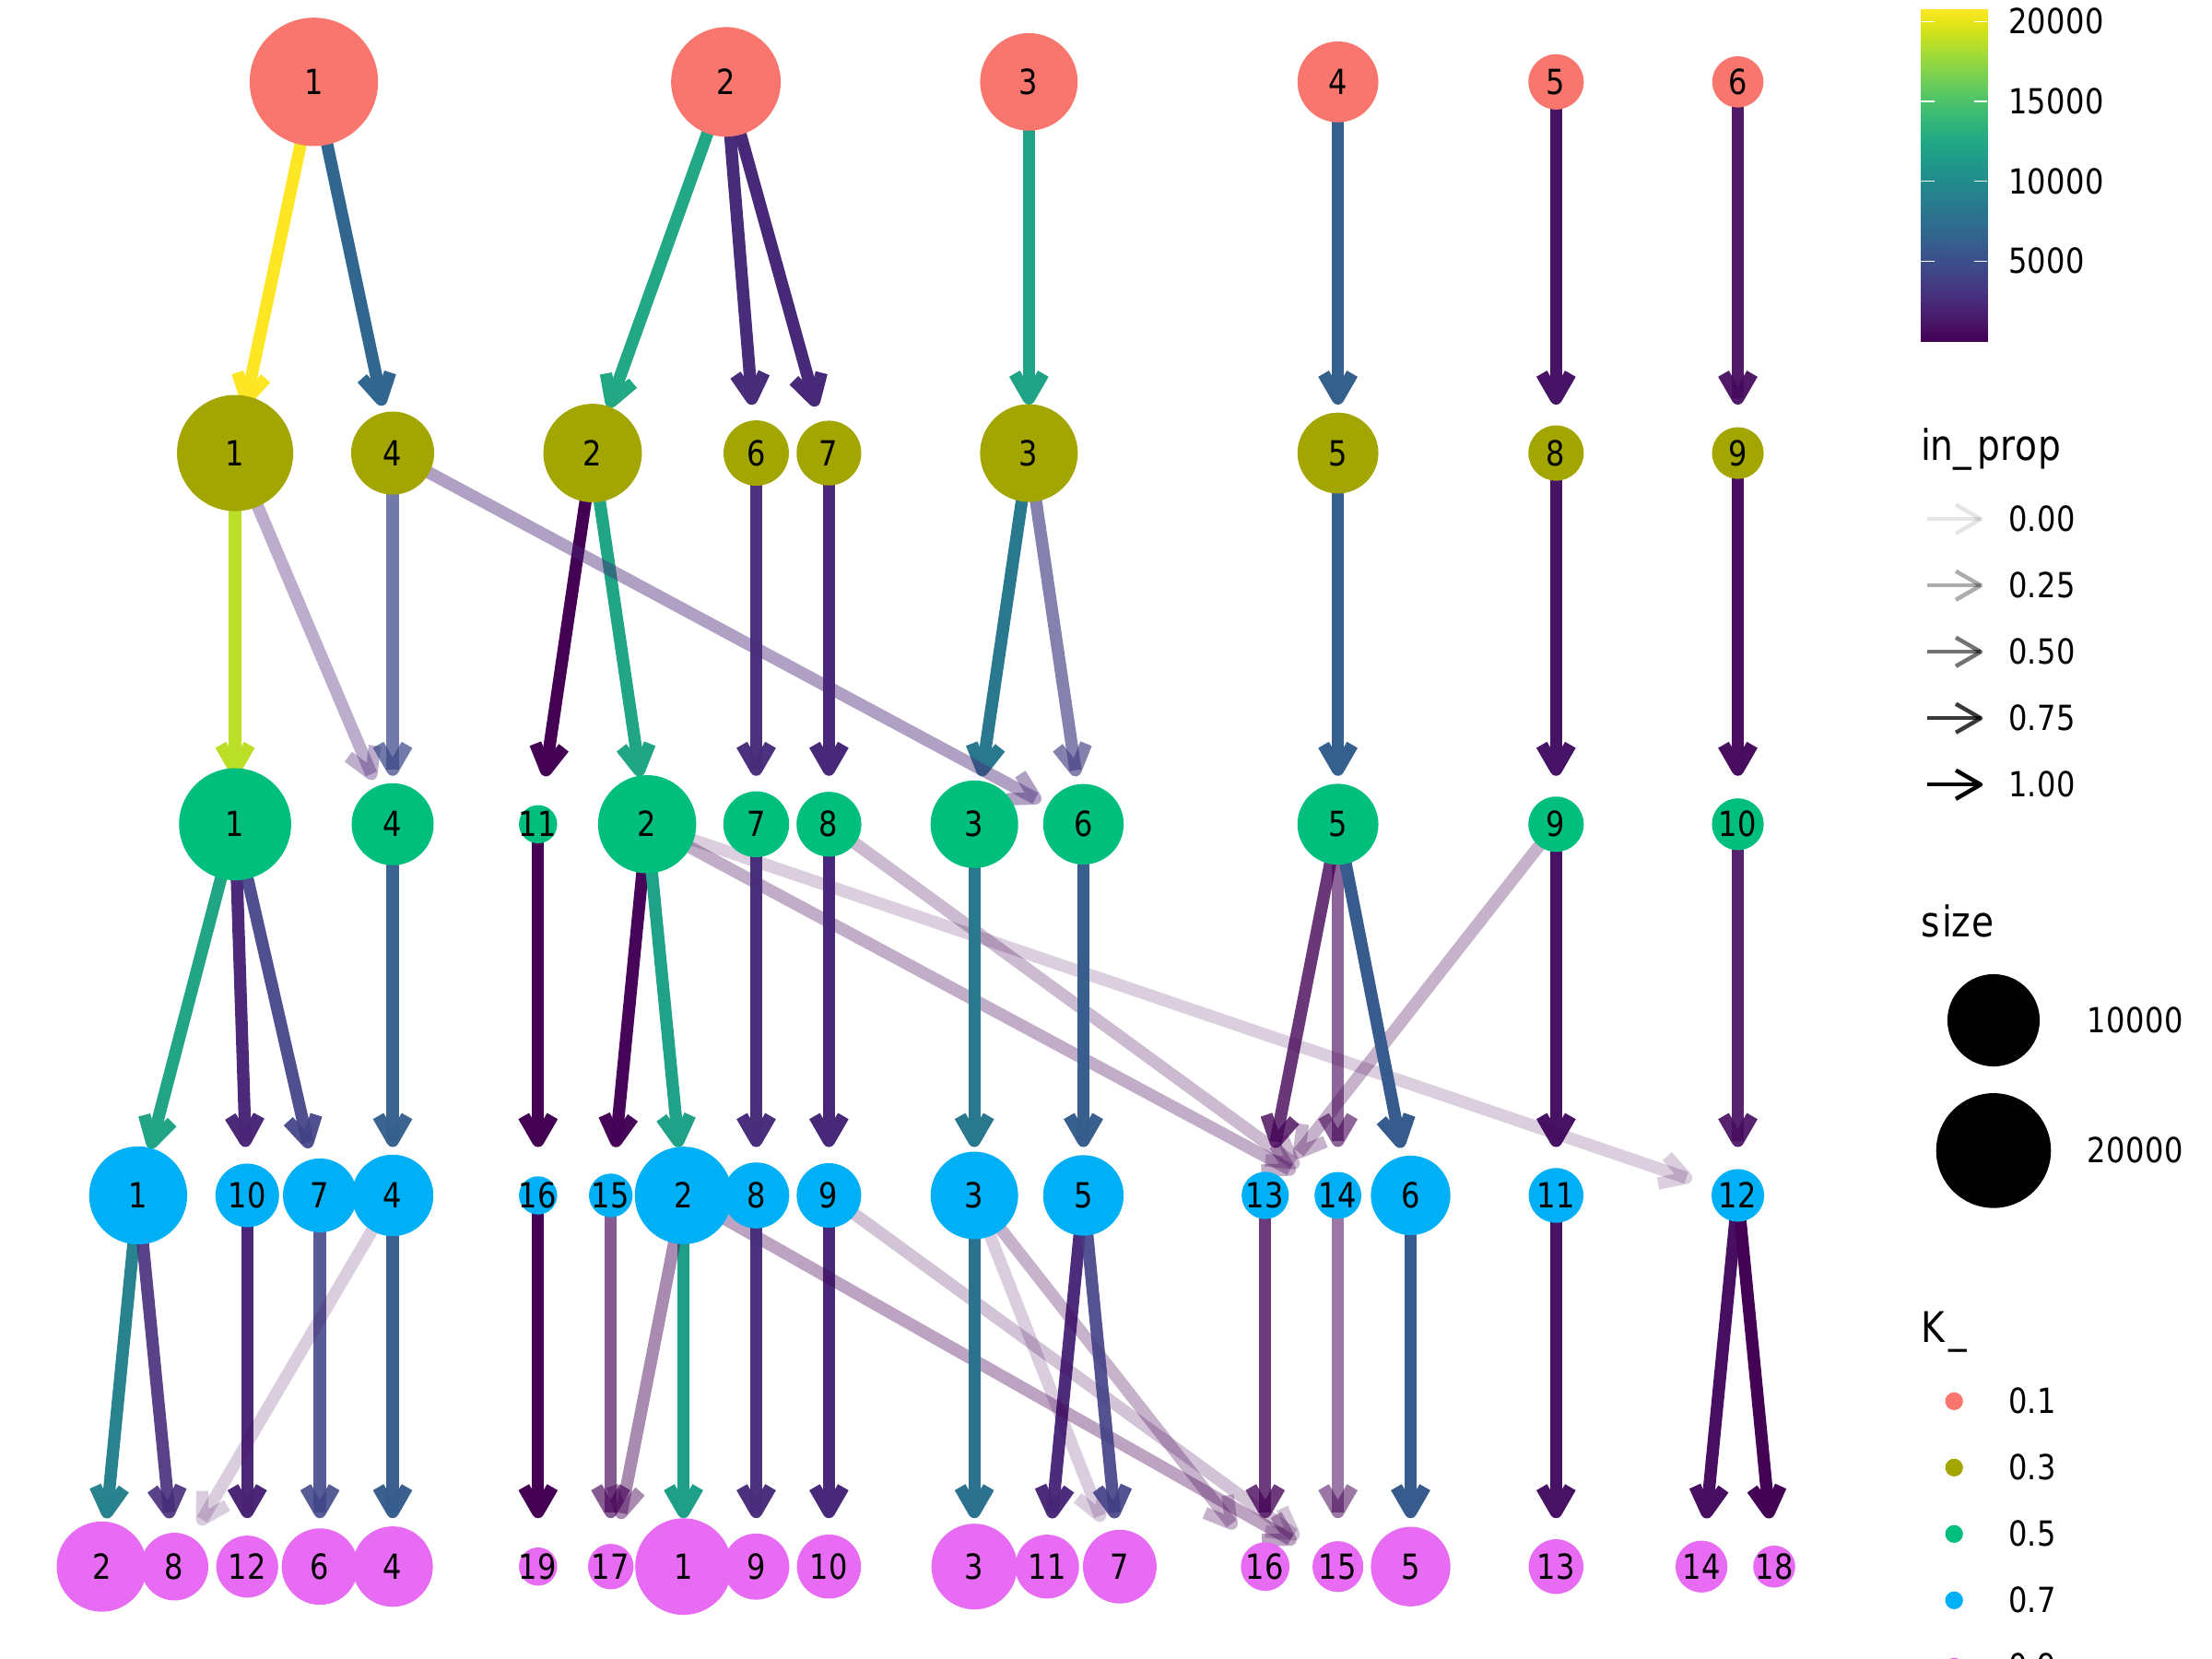

In [ ]:
# Ensure pandas to R conversion is activated
pandas2ri.activate()

# Convert pandas DataFrame to R DataFrame
r_df = pandas2ri.py2rpy(df)

# Import R packages
clustree = importr('clustree')
ggplot2 = importr('ggplot2')
ro.r('library(Cairo)')  # Load Cairo for high-quality graphics

# Define the clustree plot function in R
ro.r('''
clustree_plot <- function(df, filename) {
    # Open a PDF graphics device
    pdf(filename, width = 8, height = 6)  # Width and height in inches
    plot <- clustree(df, prefix = "K_")
    print(plot)
    dev.off()  # Close the PDF device
}
''')

# Prepare to plot
filename = 'clustree_plot_concat.pdf'
ro.globalenv['df'] = r_df
ro.globalenv['filename'] = filename

# Run the plotting function and display the result
ro.r('clustree_plot(df, filename)')

# Display the resulting image in Jupyter Notebook
from pdf2image import convert_from_path
from IPython.display import display, Image

pages = convert_from_path(filename, 300)
page = pages[0]
page